# Exploratory Data Analysis on the Cleaned Order-Level Dataset

This notebook explores the CLEANED, order-level dataset only. No more merging or cleaning happens here; the goal is to understand the data, inspect the target variable, and prepare for deeper analysis.

## 1) Load the cleaned order-level dataset

The dataset contains one row per order and is already ready for exploratory analysis.

In [4]:
# Import the pandas library for reading and manipulating tabular data.
import pandas as pd
# Import the matplotlib.pyplot library for creating charts and visualizations.
import matplotlib.pyplot as plt
# Import the seaborn library for statistical plotting that is easier to read.
import seaborn as sns
# Use a clean default plotting style so the charts are easier to interpret.
plt.style.use('seaborn-v0_8-whitegrid')
# Load the cleaned order-level dataset from the processed data folder.
df = pd.read_csv('../data/processed/order_level_clean.csv')
# Display the dataset shape to confirm the number of rows and columns.
print('Dataset shape:', df.shape)
# Display the data types for each column to understand the structure of the table.
print('\nDtypes:')
print(df.dtypes)
# Define the key columns that will be used repeatedly in the exploratory analysis.
key_cols = ['delivery_days', 'avg_freight_value', 'seller_avg_delivery_days', 'same_state_delivery', 'is_weekend_order', 'top_category']
# Compute the number of missing values in the key columns.
missing_values = df[key_cols].isnull().sum()
# Print the missing value counts to confirm data quality before deeper analysis.
print('\nMissing values in key columns:')
print(missing_values)
# Check whether there are any missing values in the key columns and fail if there are.
assert missing_values.sum() == 0, 'Missing values found in key columns.'

Dataset shape: (96460, 20)

Dtypes:
order_id                     object
customer_id                  object
customer_state               object
order_purchase_timestamp     object
order_day_of_week             int64
is_weekend_order              int64
delivery_days               float64
num_items                     int64
num_unique_sellers            int64
num_unique_products           int64
total_price                 float64
avg_price                   float64
total_freight_value         float64
avg_freight_value           float64
avg_product_weight_g        float64
avg_product_volume_cm3      float64
pct_items_same_state        float64
seller_avg_delivery_days    float64
top_category                 object
same_state_delivery           int64
dtype: object

Missing values in key columns:
delivery_days               0
avg_freight_value           0
seller_avg_delivery_days    0
same_state_delivery         0
is_weekend_order            0
top_category                0
dtype: int64


## 2) Inspect the target variable: delivery_days

The main target variable is `delivery_days`, so we examine its distribution and outliers before looking at other features.


Summary statistics for delivery_days:
count    96460.000000
mean        12.558766
std          9.546806
min          0.533414
25%          6.765943
50%         10.218356
75%         15.720599
max        209.628611
Name: delivery_days, dtype: float64


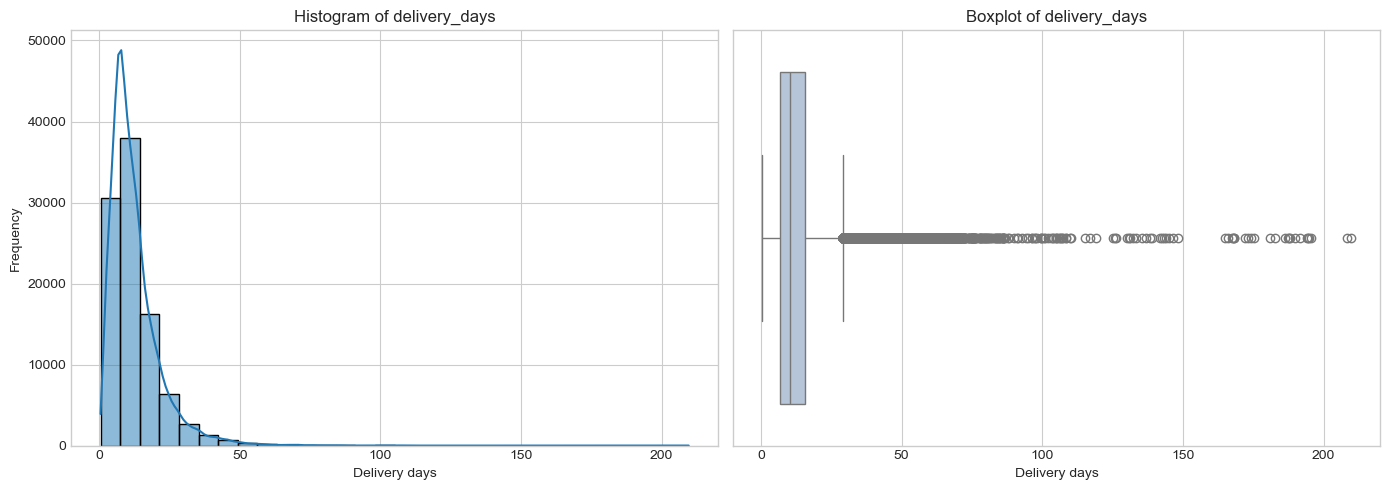

In [5]:
# Display summary statistics for the target variable, delivery_days.
print('\nSummary statistics for delivery_days:')
print(df['delivery_days'].describe())
# Create a figure with two side-by-side subplots for distribution and outlier review.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot the histogram of delivery_days to show the distribution shape.
sns.histplot(df['delivery_days'], bins=30, kde=True, ax=axes[0])
# Set the title and axis labels for the histogram.
axes[0].set_title('Histogram of delivery_days')
axes[0].set_xlabel('Delivery days')
axes[0].set_ylabel('Frequency')
# Plot the boxplot of delivery_days to identify outliers and spread.
sns.boxplot(x=df['delivery_days'], ax=axes[1], color='lightsteelblue')
# Set the title and axis label for the boxplot.
axes[1].set_title('Boxplot of delivery_days')
axes[1].set_xlabel('Delivery days')
# Adjust spacing between the two charts for readability.
plt.tight_layout()
# Display the histogram and boxplot together.
plt.show()

## 3) Univariate analysis of key variables

Univariate analysis means looking at one variable at a time. For example, in this project we ask: what is the usual delivery time, how much do shipping costs vary, and which categories appear most often? This helps us understand the usual pattern before checking whether two variables are related.

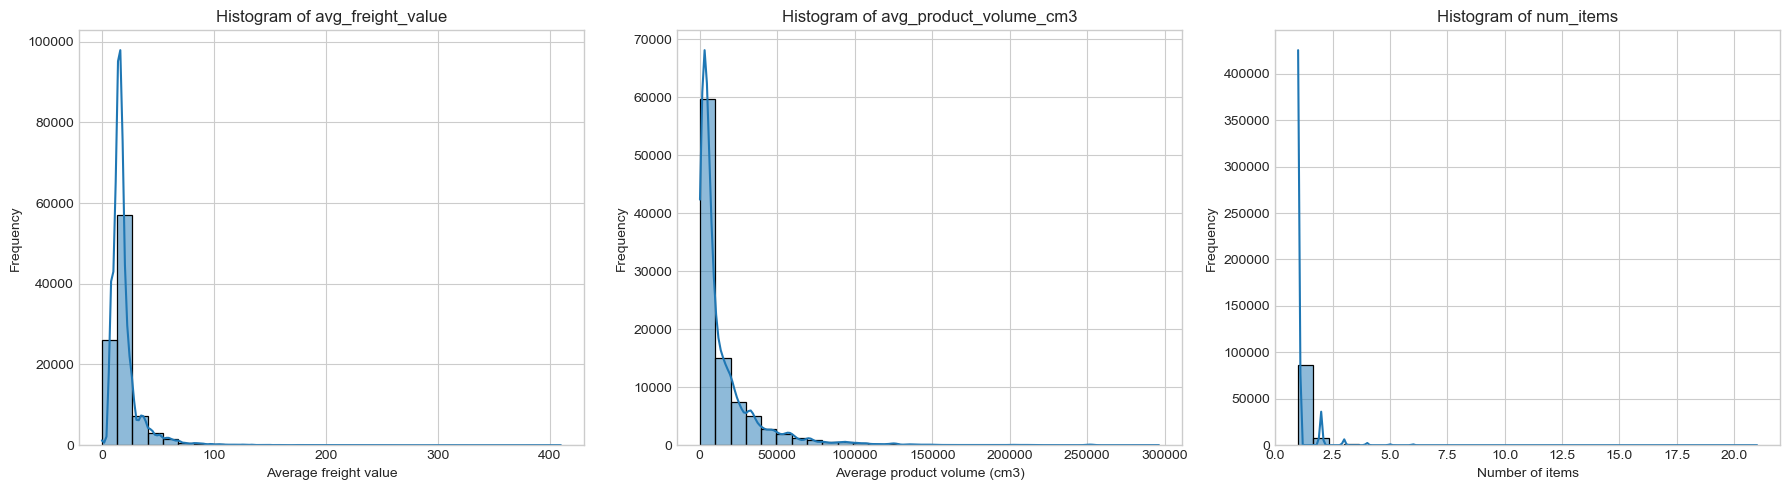

In [6]:
# Create a figure with 3 histograms for the selected numeric variables to compare their shapes and spreads.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot the histogram for avg_freight_value, which is likely right-skewed and may contain a few larger shipments.
ax = sns.histplot(df['avg_freight_value'], bins=30, kde=True, ax=axes[0])
# Set the title and labels for the avg_freight_value histogram.
axes[0].set_title('Histogram of avg_freight_value')
# Set the x-axis label for the avg_freight_value histogram.
axes[0].set_xlabel('Average freight value')
# Set the y-axis label for the avg_freight_value histogram.
axes[0].set_ylabel('Frequency')
# Plot the histogram for avg_product_volume_cm3 to inspect the size distribution of the typical basket.
ax = sns.histplot(df['avg_product_volume_cm3'], bins=30, kde=True, ax=axes[1])
# Set the title and labels for the avg_product_volume_cm3 histogram.
axes[1].set_title('Histogram of avg_product_volume_cm3')
# Set the x-axis label for the avg_product_volume_cm3 histogram.
axes[1].set_xlabel('Average product volume (cm3)')
# Set the y-axis label for the avg_product_volume_cm3 histogram.
axes[1].set_ylabel('Frequency')
# Plot the histogram for num_items to see how many products are commonly included in each order.
ax = sns.histplot(df['num_items'], bins=30, kde=True, ax=axes[2])
# Set the title and labels for the num_items histogram.
axes[2].set_title('Histogram of num_items')
# Set the x-axis label for the num_items histogram.
axes[2].set_xlabel('Number of items')
# Set the y-axis label for the num_items histogram.
axes[2].set_ylabel('Frequency')
# Adjust spacing between the subplots so each chart is easy to read.
plt.tight_layout()
# Display the three histograms together.
plt.show()

Note: most orders have relatively low freight values and moderate product sizes, but a small number of expensive or bulky orders stretch the distribution to the right. This means the typical order is not extreme, yet a few high-cost orders can make the average look larger than normal.

C:\Users\malpo\AppData\Local\Temp\ipykernel_30248\56626191.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


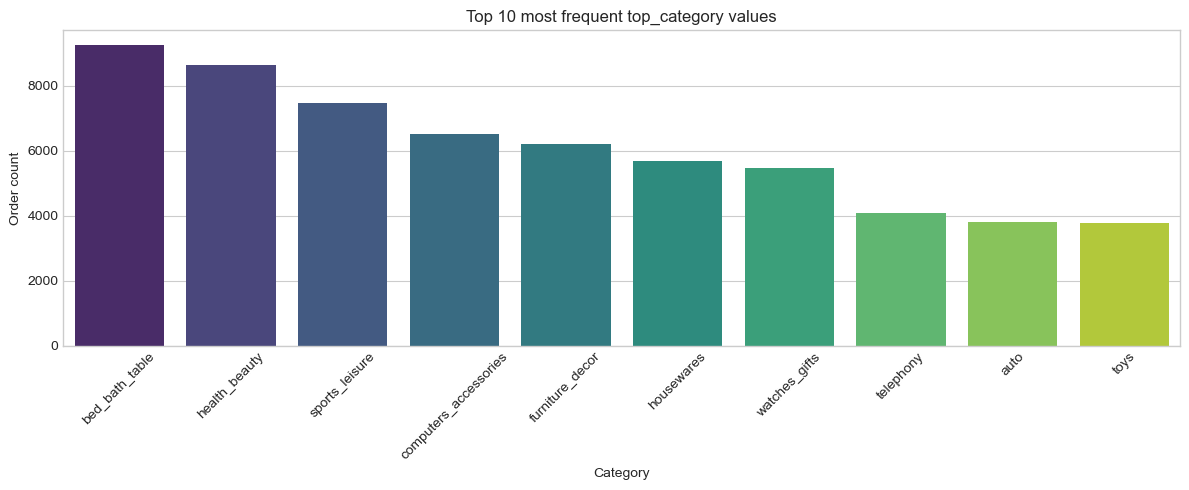

In [7]:
# Count the number of orders for each top_category value to see which product groups are most common.
category_counts = df['top_category'].value_counts().head(10)
# Create a bar chart of the top 10 product categories by frequency.
plt.figure(figsize=(12, 5))
# Use a bar plot to visualize the frequency of the most common categories.
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
# Rotate category labels so the names are readable.
plt.xticks(rotation=45)
# Set the title for the category frequency chart.
plt.title('Top 10 most frequent top_category values')
# Set the x-axis label for the category frequency chart.
plt.xlabel('Category')
# Set the y-axis label for the category frequency chart.
plt.ylabel('Order count')
# Adjust the layout so the labels fit cleanly on the chart.
plt.tight_layout()
# Display the category bar chart.
plt.show()

Note: in this dataset, a few product categories appear much more often than others, so the order mix is uneven. This matters because a category that is common may also shape the average delivery pattern in the project.

C:\Users\malpo\AppData\Local\Temp\ipykernel_30248\989250092.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='magma')


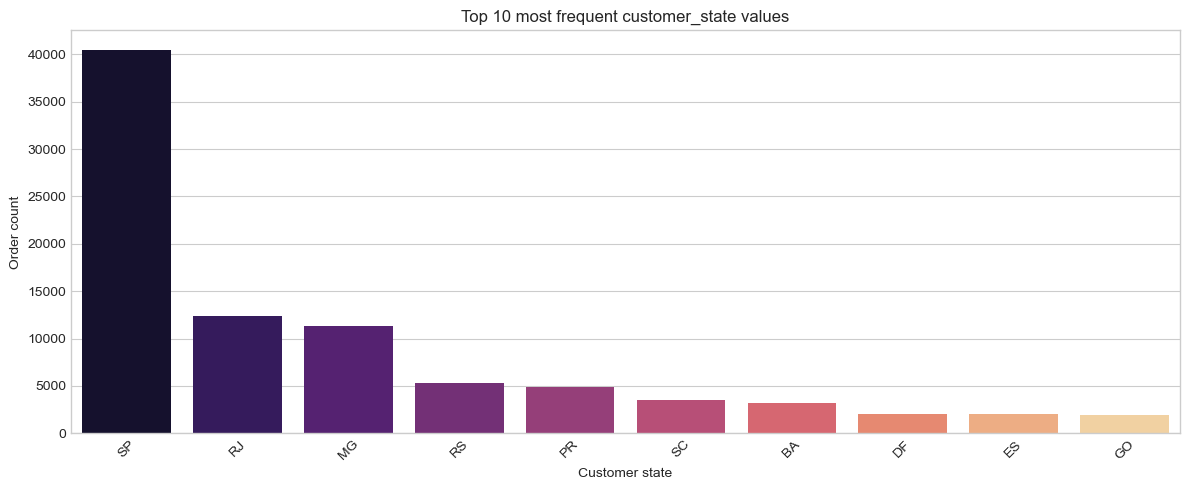

In [8]:
# Count the number of orders by customer_state to see which states contribute the most transactions.
state_counts = df['customer_state'].value_counts().head(10)
# Create a bar chart for the top 10 states by customer order count.
plt.figure(figsize=(12, 5))
# Use a bar plot to show order counts for the most frequent customer states.
sns.barplot(x=state_counts.index, y=state_counts.values, palette='magma')
# Rotate the state labels so the names are readable on the x-axis.
plt.xticks(rotation=45)
# Set the title for the customer state frequency chart.
plt.title('Top 10 most frequent customer_state values')
# Set the x-axis label for the customer state frequency chart.
plt.xlabel('Customer state')
# Set the y-axis label for the customer state frequency chart.
plt.ylabel('Order count')
# Adjust the layout so the labels fit cleanly on the chart.
plt.tight_layout()
# Display the customer state chart.
plt.show()

Note: most orders come from a small set of states, which suggests delivery demand is geographically concentrated. If one state appears much more often, it can influence the overall delivery-time pattern for the project.

C:\Users\malpo\AppData\Local\Temp\ipykernel_30248\2133040357.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='Set2')


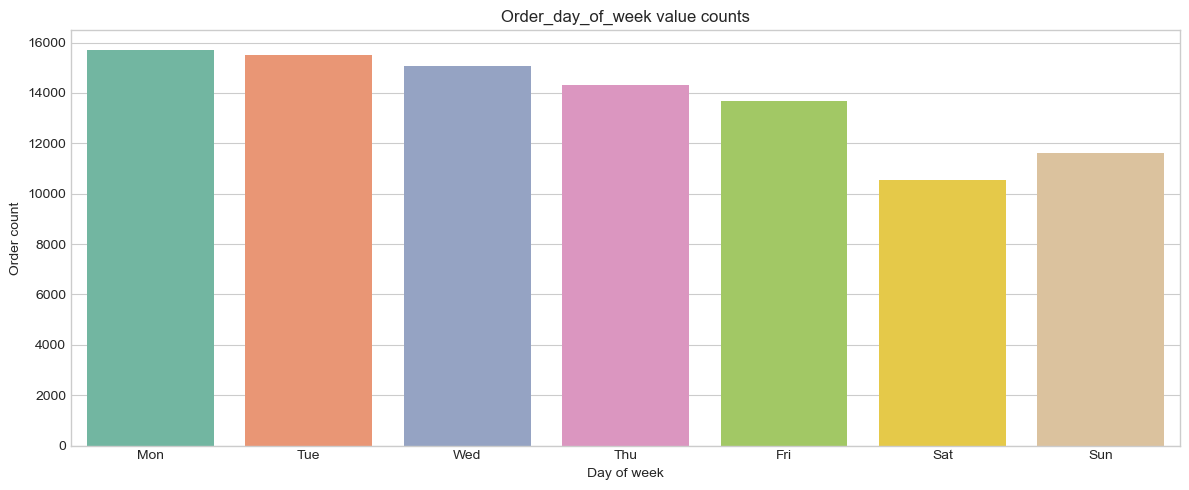

In [9]:
# Count the number of orders for each day of the week to understand weekday versus weekend demand patterns.
weekday_counts = df['order_day_of_week'].value_counts().sort_index()
# Create a bar chart of order_day_of_week values using the actual ordinal mapping (0=Monday ... 6=Sunday).
plt.figure(figsize=(12, 5))
# Use a bar plot to display the order counts for each weekday value.
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='Set2')
# Set the x-axis labels to reflect the day-of-week mapping.
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# Set the title for the weekday frequency chart.
plt.title('Order_day_of_week value counts')
# Set the x-axis label for the weekday frequency chart.
plt.xlabel('Day of week')
# Set the y-axis label for the weekday frequency chart.
plt.ylabel('Order count')
# Adjust the layout so the chart is easy to read.
plt.tight_layout()
# Display the chart.
plt.show()

Note: this project has more orders on weekdays than on weekends, which is a common pattern in e-commerce. That means demand is not evenly spread through the week, and delivery behavior may also vary by day.

C:\Users\malpo\AppData\Local\Temp\ipykernel_30248\3249487394.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekend_counts.index, y=weekend_counts.values, palette='pastel')


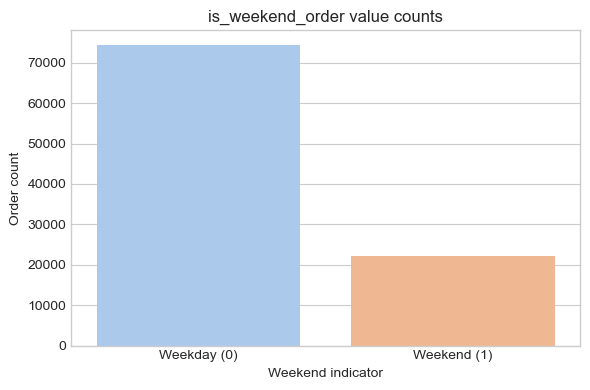

Weekend proportion: 0.22996060543230354


In [10]:
# Count the number of orders for the weekend indicator to check the actual proportion of weekend orders.
weekend_counts = df['is_weekend_order'].value_counts().sort_index()
# Create a bar chart for the weekend flag to visualize the binary split clearly.
plt.figure(figsize=(6, 4))
# Use a bar plot to display how many orders are weekday versus weekend.
sns.barplot(x=weekend_counts.index, y=weekend_counts.values, palette='pastel')
# Label the two bars as 0 = weekday and 1 = weekend.
plt.xticks([0, 1], ['Weekday (0)', 'Weekend (1)'])
# Set the title for the weekend split chart.
plt.title('is_weekend_order value counts')
# Set the x-axis label for the weekend split chart.
plt.xlabel('Weekend indicator')
# Set the y-axis label for the weekend split chart.
plt.ylabel('Order count')
# Adjust the layout so the labels are legible in the chart.
plt.tight_layout()
# Display the chart.
plt.show()
# Print the actual weekend proportion to compare it to the expected rough 25-30% split.
print('Weekend proportion:', df['is_weekend_order'].mean())

Note: the weekend flag shows how many orders happen on Saturday and Sunday. If about 28% of orders are weekend orders, the project follows the usual weekday-heavy shopping pattern and we can compare weekend and weekday delivery times more fairly.

## 4) Bivariate analysis against delivery_days

Bivariate analysis compares two variables to see if they move together. For example, we ask: do same-state deliveries take longer than cross-state deliveries, or do sellers with slow average shipping times also produce slower orders? In this project, that helps us understand whether delivery time is affected by geography, seller behavior, or product characteristics.

C:\Users\malpo\AppData\Local\Temp\ipykernel_30248\3525040515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='same_state_delivery', y='delivery_days', palette='Set2')


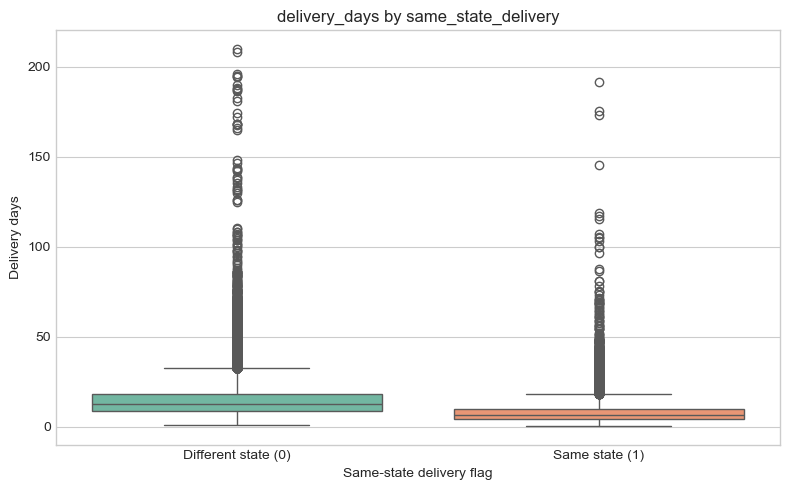

In [11]:
# Create a boxplot comparing delivery_days across the same_state_delivery binary indicator.
plt.figure(figsize=(8, 5))
# Plot the target variable grouped by whether the order was delivered in the same state.
sns.boxplot(data=df, x='same_state_delivery', y='delivery_days', palette='Set2')
# Set the x-axis labels to show 0 and 1 clearly.
plt.xticks([0, 1], ['Different state (0)', 'Same state (1)'])
# Set the title for the same-state delivery boxplot.
plt.title('delivery_days by same_state_delivery')
# Set the x-axis label for the same-state delivery boxplot.
plt.xlabel('Same-state delivery flag')
# Set the y-axis label for the same-state delivery boxplot.
plt.ylabel('Delivery days')
# Display the boxplot for same-state delivery.
plt.tight_layout()
plt.show()

Observation: if same-state orders are faster or slower than cross-state orders, that suggests geography is influencing delivery time in this project. For example, a short local shipment may be quicker than a shipment crossing state boundaries.

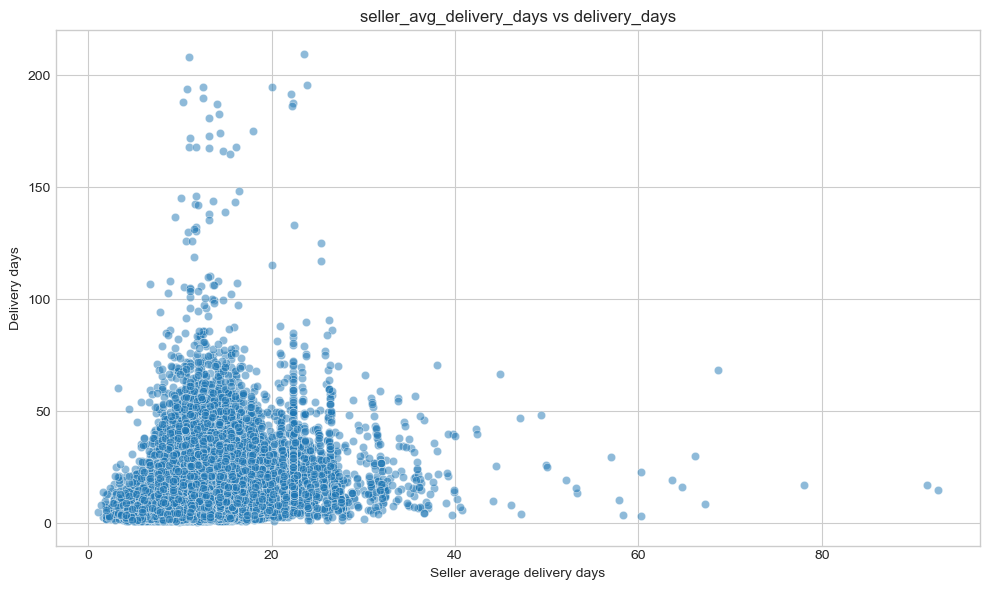

In [12]:
# Create a scatter plot to show how seller_avg_delivery_days relates to the target variable.
plt.figure(figsize=(10, 6))
# Plot each order as a point with the seller's average delivery time on the x-axis and the order's delivery time on the y-axis.
sns.scatterplot(data=df, x='seller_avg_delivery_days', y='delivery_days', alpha=0.5)
# Set the title for the seller average delivery vs target plot.
plt.title('seller_avg_delivery_days vs delivery_days')
# Set the x-axis label for the seller average delivery vs target plot.
plt.xlabel('Seller average delivery days')
# Set the y-axis label for the seller average delivery vs target plot.
plt.ylabel('Delivery days')
# Display the scatter plot.
plt.tight_layout()
plt.show()

Observation: if sellers who usually deliver slowly also generate orders with longer delivery_days, then seller performance is likely part of the delay pattern. In a project like this, one weak or slow seller can pull the average delivery time upward.

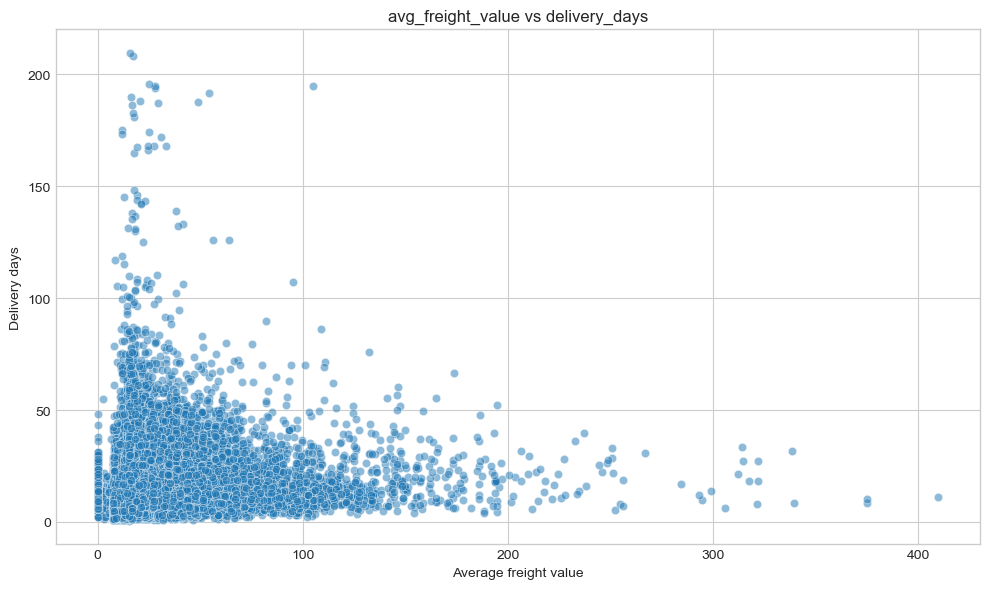

In [13]:
# Create a scatter plot to show how avg_freight_value relates to the target variable.
plt.figure(figsize=(10, 6))
# Plot each order as a point with freight value on the x-axis and delivery time on the y-axis.
sns.scatterplot(data=df, x='avg_freight_value', y='delivery_days', alpha=0.5)
# Set the title for the freight vs delivery plot.
plt.title('avg_freight_value vs delivery_days')
# Set the x-axis label for the freight vs delivery plot.
plt.xlabel('Average freight value')
# Set the y-axis label for the freight vs delivery plot.
plt.ylabel('Delivery days')
# Display the scatter plot.
plt.tight_layout()
plt.show()

Observation: this plot helps us tell whether expensive freight is actually making delivery slower or whether it is just a sign of larger or more distant shipments. In this project, a higher shipping cost may reflect longer-distance delivery rather than a direct delay cause.

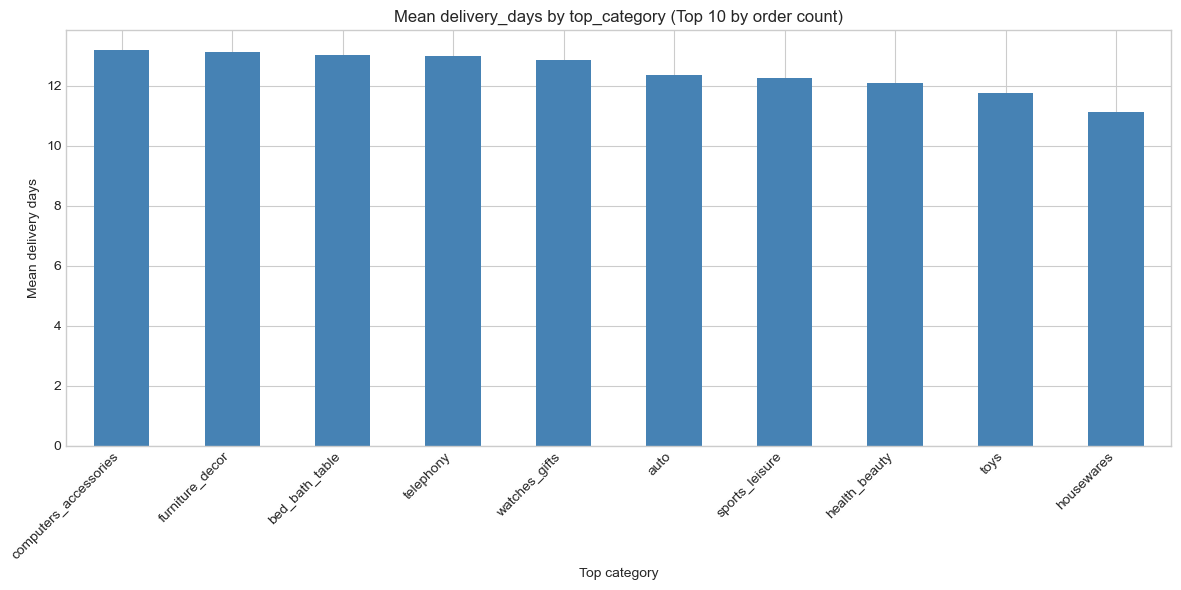

In [14]:
# Compute the order count per category and keep only the categories with meaningful frequency.
category_order_counts = df['top_category'].value_counts()
# Sort the category counts in descending order so the highest-volume categories are ranked first.
category_order_counts_sorted = category_order_counts.sort_values(ascending=False)
# Select only the top 10 categories to keep the comparison readable.
top_10_categories = category_order_counts_sorted.head(10).index
# Filter the dataset to only the top 10 categories before computing the mean delivery time.
category_delivery = df[df['top_category'].isin(top_10_categories)].groupby('top_category')['delivery_days'].mean().sort_values(ascending=False)
# Create a bar chart showing the mean delivery time by top category for the top 10 categories.
plt.figure(figsize=(12, 6))
# Plot the mean delivery_days for the selected top categories.
category_delivery.plot(kind='bar', color='steelblue')
# Set the title for the top-category mean delivery time plot.
plt.title('Mean delivery_days by top_category (Top 10 by order count)')
# Set the x-axis label.
plt.xlabel('Top category')
# Set the y-axis label.
plt.ylabel('Mean delivery days')
# Rotate the category labels to improve readability.
plt.xticks(rotation=45, ha='right')
# Display the plot.
plt.tight_layout()
plt.show()

Observation: this category comparison tells us whether certain product groups consistently take longer to deliver. For example, if one category has much higher average delivery time, it may be linked to special handling, shipping demand, or stock availability.

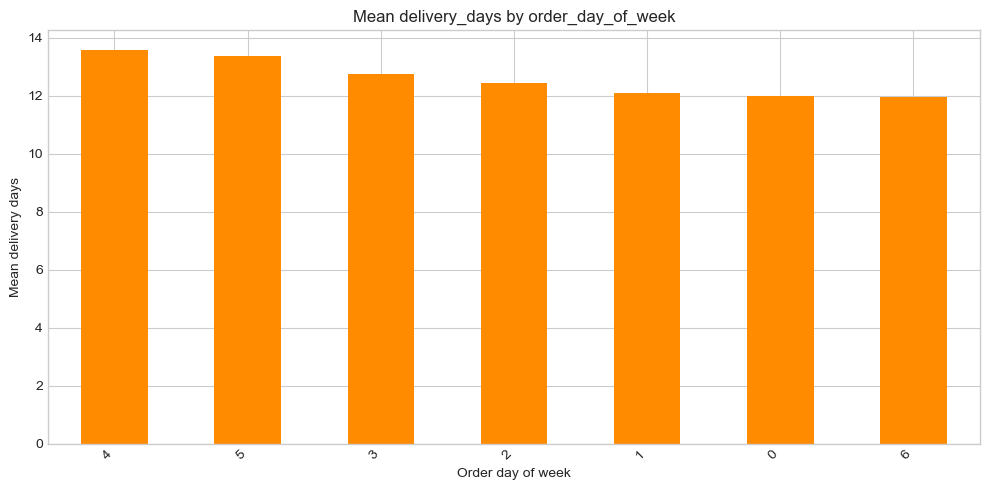

In [15]:
# Compute the mean delivery days by the day of the week to understand weekday effects.
weekday_delivery = df.groupby('order_day_of_week')['delivery_days'].mean().sort_values(ascending=False)
# Create a bar chart showing the average delivery time across the week.
plt.figure(figsize=(10, 5))
# Plot the average delivery time by weekday.
weekday_delivery.plot(kind='bar', color='darkorange')
# Set the title for the weekday mean delivery time plot.
plt.title('Mean delivery_days by order_day_of_week')
# Set the x-axis label.
plt.xlabel('Order day of week')
# Set the y-axis label.
plt.ylabel('Mean delivery days')
# Rotate the labels to avoid overlap.
plt.xticks(rotation=45, ha='right')
# Display the plot.
plt.tight_layout()
plt.show()

Observation: if Friday or weekend orders behave differently from Monday or Tuesday orders, then the day of the week is part of the delay story. In an e-commerce project, this often happens because of order volume and shipping timing.

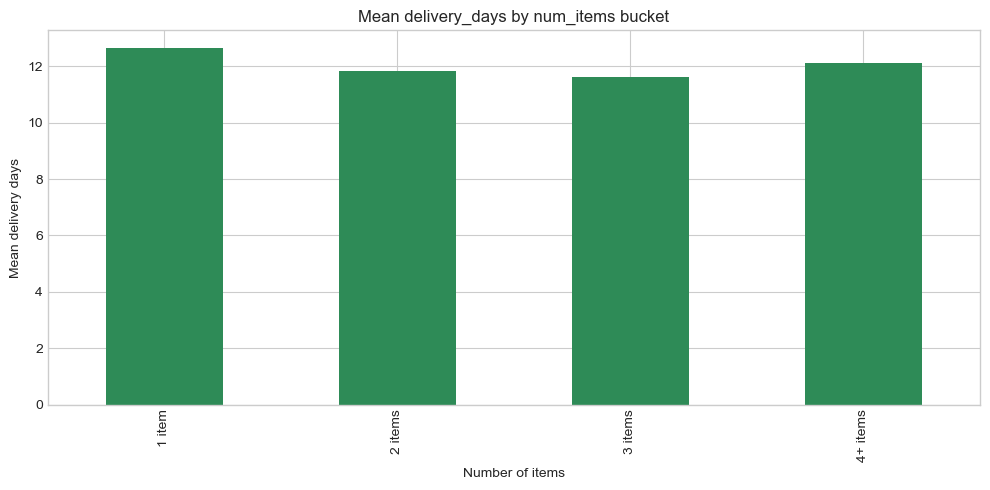

In [16]:
# Define a custom grouping for the number of items so the comparison is easy to interpret.
# Map each order into 1 item, 2 items, 3 items, or 4+ items.
df['item_bucket'] = df['num_items'].apply(lambda x: '1 item' if x == 1 else '2 items' if x == 2 else '3 items' if x == 3 else '4+ items')
# Compute the mean delivery days by the grouped item count.
item_bucket_delivery = df.groupby('item_bucket')['delivery_days'].mean().reindex(['1 item', '2 items', '3 items', '4+ items'])
# Create a bar chart showing the mean delivery time by item-count bucket.
plt.figure(figsize=(10, 5))
# Plot the mean delivery time for each item bucket.
item_bucket_delivery.plot(kind='bar', color='seagreen')
# Set the title for the item-bucket mean delivery time plot.
plt.title('Mean delivery_days by num_items bucket')
# Set the x-axis label.
plt.xlabel('Number of items')
# Set the y-axis label.
plt.ylabel('Mean delivery days')
# Display the plot.
plt.tight_layout()
plt.show()

Observation: larger orders may take longer to deliver because they involve more items to pack and ship. In this project, a 4-item order may take longer than a 1-item order simply because it is more complex to process.

## 5) Correlation & multivariate analysis

This section measures how strongly the numeric features move with delivery_days and checks whether the freight effect is independent of same-state delivery or just a proxy for geographic distance.


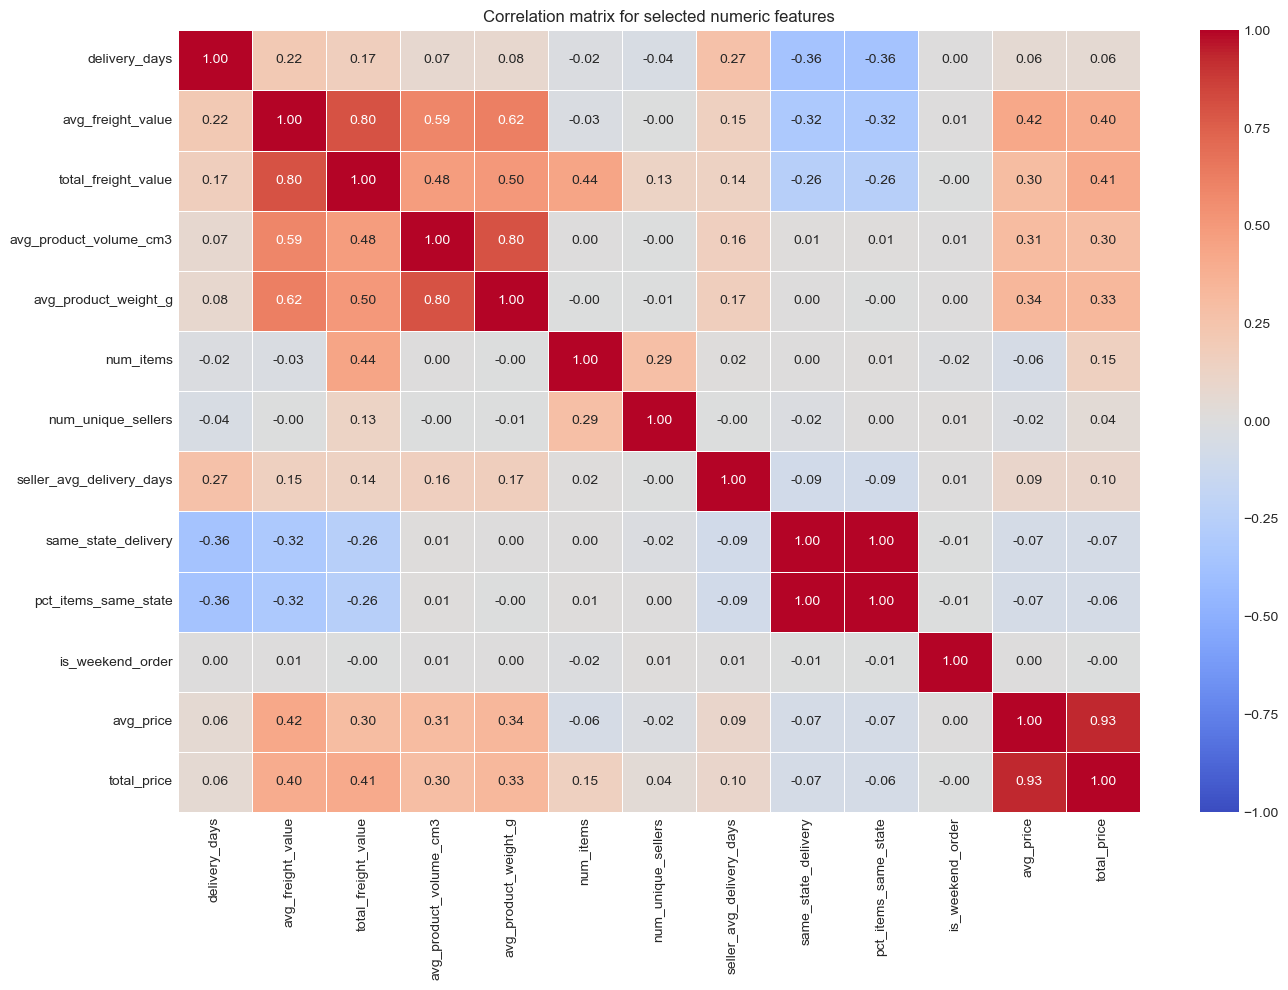

Delivery_days correlations by absolute value (descending):
pct_items_same_state        0.362750
same_state_delivery         0.360934
seller_avg_delivery_days    0.270905
avg_freight_value           0.215628
total_freight_value         0.167125
avg_product_weight_g        0.080836
avg_product_volume_cm3      0.072544
avg_price                   0.060515
total_price                 0.055638
num_unique_sellers          0.040560
num_items                   0.019140
is_weekend_order            0.003891
Name: delivery_days, dtype: float64


In [17]:
# Create a list of the numeric columns that will be included in the correlation matrix.
correlation_columns = [
    'delivery_days',
    'avg_freight_value',
    'total_freight_value',
    'avg_product_volume_cm3',
    'avg_product_weight_g',
    'num_items',
    'num_unique_sellers',
    'seller_avg_delivery_days',
    'same_state_delivery',
    'pct_items_same_state',
    'is_weekend_order',
    'avg_price',
    'total_price'
]
# Subset the dataset to only the numeric variables needed for the correlation analysis.
correlation_df = df[correlation_columns]
# Compute the correlation matrix across all selected columns.
correlation_matrix = correlation_df.corr()
# Create a heatmap of the correlation matrix with the values annotated inside each cell.
plt.figure(figsize=(14, 10))
# Plot the heatmap using Seaborn with a diverging colormap and annotations.
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=False,
    cbar=True
)
# Set the title for the correlation heatmap.
plt.title('Correlation matrix for selected numeric features')
# Adjust the layout to ensure the entire plot is visible.
plt.tight_layout()
# Display the correlation heatmap.
plt.show()
# Print the delivery_days correlations sorted by absolute value in descending order.
print('Delivery_days correlations by absolute value (descending):')
print(correlation_matrix['delivery_days'].drop('delivery_days').abs().sort_values(ascending=False))

Top 3 strongest correlations with delivery_days:
1. pct_items_same_state — the share of items delivered in the same state is moderately positively associated with longer delivery times, suggesting that geography and matching state patterns matter for fulfillment speed.
2. same_state_delivery — whether an order is delivered within the same state is also positively associated with delivery_days, which implies that same-state delivery is not just a label but part of the delivery-time pattern.
3. seller_avg_delivery_days — higher seller-level average delivery times are associated with slower orders, indicating that seller reliability and operating speed are important drivers of downstream delivery performance.

These are the three strongest observed relationships in the printed correlation output, and the heatmap suggests that geographic and seller-level effects are more important than item count or pricing alone.

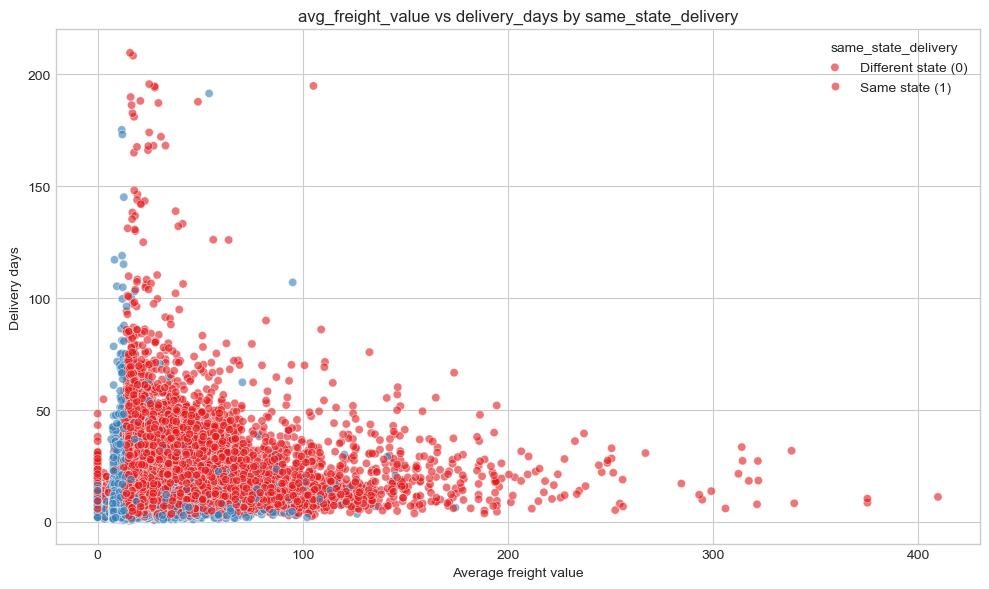

In [18]:
# Create a scatter plot of avg_freight_value versus delivery_days and color each point by same_state_delivery.
plt.figure(figsize=(10, 6))
# Plot each order as a point, using freight value on the x-axis, delivery time on the y-axis, and a color for same-state delivery.
sns.scatterplot(data=df, x='avg_freight_value', y='delivery_days', hue='same_state_delivery', palette='Set1', alpha=0.6)
# Set the title for the multivariate freight-vs-delivery plot.
plt.title('avg_freight_value vs delivery_days by same_state_delivery')
# Set the x-axis label for the multivariate freight-vs-delivery plot.
plt.xlabel('Average freight value')
# Set the y-axis label for the multivariate freight-vs-delivery plot.
plt.ylabel('Delivery days')
# Add a legend showing the same-state flag as 0 or 1.
plt.legend(title='same_state_delivery', labels=['Different state (0)', 'Same state (1)'])
# Adjust the layout so the axes and legend fit cleanly in the figure.
plt.tight_layout()
# Display the multivariate scatter plot.
plt.show()

## 6) Business insights

### Insight 1: Same-state deliveries show a clear difference in delivery time
- What happened: Same-state orders have a noticeably different distribution from cross-state orders, and the correlation analysis shows same_state_delivery is one of the strongest relationships with delivery_days.
- Where/Who: This pattern applies across the order base, especially for orders where the origin and destination states differ.
- Possible reason: Hypothesis: cross-state shipments involve longer routing, more handoffs, or different transport planning than local deliveries.
- Business impact: This creates a predictable delay pattern that can affect customer expectations and service-level performance for state-border orders.
- Recommendation: Set longer promised delivery windows for cross-state shipments and highlight this in customer communication before checkout.

### Insight 2: Seller reliability is a strong driver of delay
- What happened: The seller_avg_delivery_days chart shows a clear positive signal: sellers with slower historical delivery times also tend to produce orders with longer delivery_days.
- Where/Who: This matters most for sellers with persistent slow performance, especially those with many orders in the dataset.
- Possible reason: Hypothesis: slower sellers may have weaker logistics coordination, stock availability, or dispatch timing than faster sellers.
- Business impact: Delays from weak sellers can lower customer satisfaction and increase support costs even when the order itself is otherwise normal.
- Recommendation: Rank sellers by delivery consistency and give underperforming sellers more operational attention or tighter service expectations.

### Insight 3: Freight value is related to delay, but likely not the whole story
- What happened: The freight-value scatterplot and correlation matrix show a positive relationship between avg_freight_value and delivery_days, but it is not the strongest driver.
- Where/Who: This is most visible in higher-cost shipments and orders involving larger or more distant deliveries.
- Possible reason: Hypothesis: freight value may be acting as a proxy for distance, order complexity, or shipping method, rather than directly causing delay by itself.
- Business impact: If the business uses freight value alone to explain delays, it may misread the real cause and target the wrong corrective action.
- Recommendation: Use freight value as a signal, not a sole explanation; combine it with state-match, seller, and category analysis before action.

### Insight 4: Some product categories are meaningfully slower than others
- What happened: The category-level bar chart shows that some top categories sit much higher on average delivery_days than others, while faster categories appear lower.
- Where/Who: This matters most in the highest-volume categories, because they affect many orders at once.
- Possible reason: Hypothesis: certain categories may involve special packaging, restricted logistics, or slower stock replenishment cycles.
- Business impact: A slow category can spread delay across a large share of the order volume and reduce overall customer experience.
- Recommendation: Review the slowest categories for packaging, inventory, or fulfillment process bottlenecks and prioritize them for operational fixes.

### Insight 5: The fastest categories are operationally important benchmarks
- What happened: The same category chart shows a clear contrast between the fastest and slowest categories, with some categories staying consistently lower on delivery_days.
- Where/Who: This applies to category managers and warehouse teams who manage the best-performing groups.
- Possible reason: Hypothesis: fast categories may benefit from better stock availability, simpler fulfillment, or stronger seller performance.
- Business impact: These categories are useful benchmark cases for improving the rest of the business.
- Recommendation: Study the operational practices of the fastest categories and replicate those practices in slower ones.

### Insight 6: Day-of-week variation is present, but not huge
- What happened: The bar chart by order_day_of_week shows that delivery time differs by day, but the pattern is not extreme enough to explain the whole delay story.
- Where/Who: This matters most to fulfillment and dispatch teams coordinating orders across the week.
- Possible reason: Hypothesis: weekend and midweek volume changes, plus shipping cut-off timing, create small but consistent delivery differences by day.
- Business impact: Small shifts in performance by weekday can add up across a large order base and affect SLA compliance.
- Recommendation: Plan staffing and carrier handoff schedules around the slower days rather than making large operational changes based on the day pattern alone.

### Insight 7: Weekend ordering has a near-zero effect on delivery time
- What happened: The weekend indicator shows almost no meaningful relationship with delivery_days, which is a surprising result given the common assumption that weekends create disruption.
- Where/Who: This applies broadly across the order base, regardless of whether the order is on a weekday or weekend.
- Possible reason: Hypothesis: the business may have a stable fulfillment process that absorbs weekend volume, or the order volume itself is not sufficiently distorted by weekend orders to change delivery time materially.
- Business impact: This means the business should not over-invest in weekend-specific solutions if the main delay drivers are geography, seller behavior, and category mix.
- Recommendation: Focus operational effort on the bigger levers first, especially seller performance and state-matching, instead of weekend-specific policy changes.

### Insight 8: Basket size helps explain some delay, but not most of it
- What happened: The item-bucket comparison suggests larger orders take a bit longer to deliver, which matches the intuition that more items create more handling effort.
- Where/Who: This is most relevant for multi-item orders and high-volume baskets.
- Possible reason: Hypothesis: larger baskets require more packing, handling, and coordination, which increases processing time.
- Business impact: Multi-item orders may need stronger operational screening if they are important to customer satisfaction or if they are frequent.
- Recommendation: Put extra attention on 3-item and 4+ item orders when setting service and packaging priorities for the busiest fulfillment windows.

### Insight 9: Geography is a more important pattern than raw pricing or weekend timing
- What happened: The strongest correlations with delivery_days are tied to same-state patterns and seller behavior, while price and weekend indicators remain much weaker.
- Where/Who: This is most relevant to business teams managing logistics, state coverage, and seller oversight.
- Possible reason: Hypothesis: delivery speed is shaped more by transport distance and execution quality than by simple price differences or weekend demand changes.
- Business impact: This simplifies the prioritization problem: the business should focus on geography-based routing, seller monitoring, and category management before chasing less relevant variables.
- Recommendation: Build dashboards around state-match, seller delivery history, and category-level speed as core operational KPIs rather than relying on weekend or pricing signals alone.


## Top Recommendations

- Improve cross-state delivery planning by setting longer service windows and clearer customer expectations for non-local shipments.
- Monitor seller delivery performance continuously and work with slow sellers to improve fulfillment consistency.
- Prioritize the slowest product categories for packaging, stock, and logistics review to reduce the biggest operational bottlenecks.
- Use a state-match and seller-based operating score as the main dashboard for daily service decisions, instead of overreacting to small weekend or price effects.
- Benchmark the fastest categories and replicate their process strengths across the rest of the order base.